<a href="https://colab.research.google.com/github/alihammadeh/selfdriving/blob/main/image_resize.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
drive_folder_path = '/content/drive/My Drive/selfdriving'

In [ ]:
images_path = os.path.join(drive_folder_path, 'export')
image_ids_annos_path = os.path.join(drive_folder_path, 'image_ids_annotations.json')
annos_path = os.path.join(images_path, '_annotations.coco.json')

In [ ]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from glob import glob
import IPython.display as display
import json

In [ ]:
images = glob(images_path + '/*.jpg')
resized_image_path = os.path.join(drive_folder_path, 'resized_images')

(1200, 1920, 3)


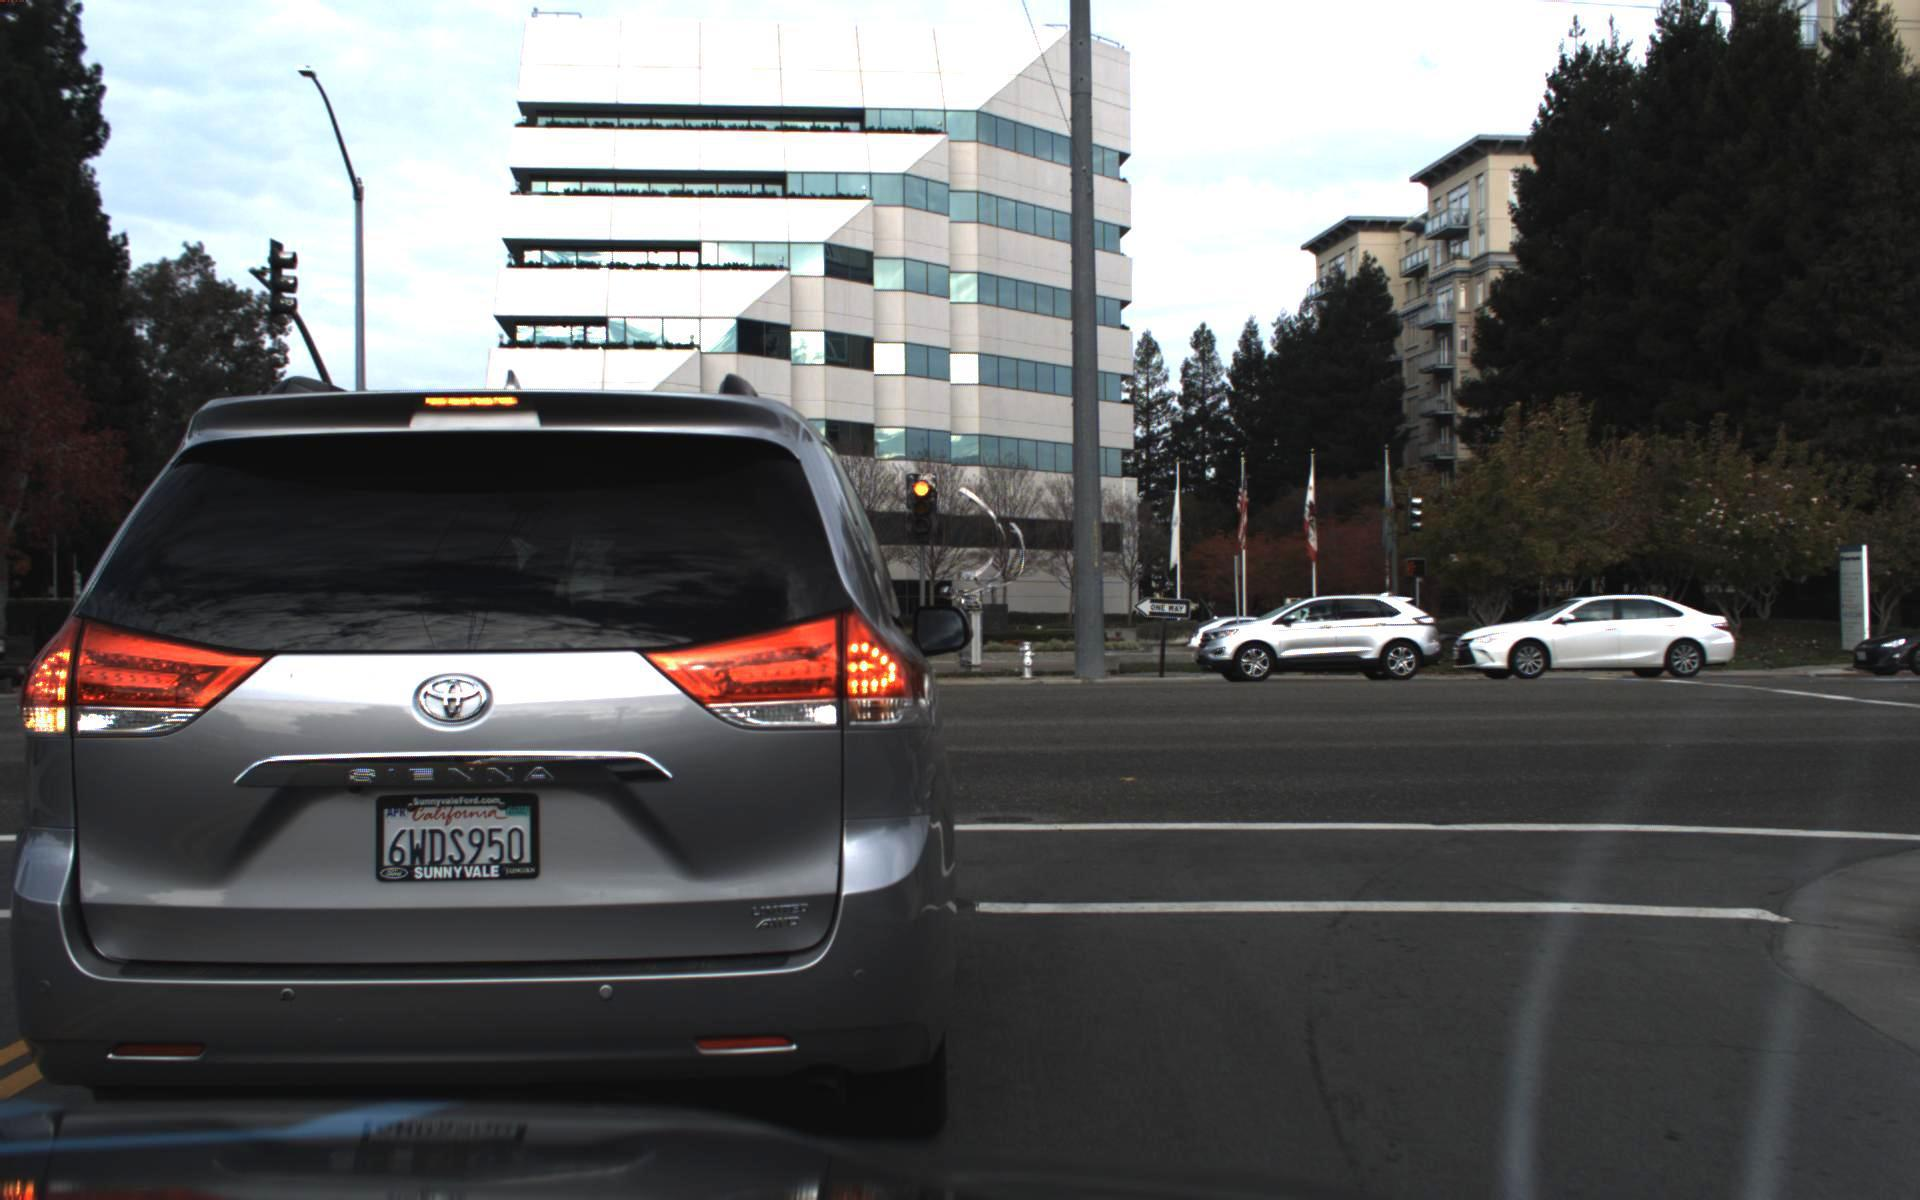

In [ ]:
image = Image.open(images[0])
image_array = np.array(image)
print(image_array.shape)
display.display(image)

In [ ]:
file = open(annos_path)
annos = json.load(file)
file = open(image_ids_annos_path)
image_ids_annos = json.load(file)

In [ ]:
image_id_path = {}
for image in annos['images']:
    image_id_path[image['id']] = image

In [ ]:
annotations_resized = {}
for image in image_id_path:
    try:
      img = Image.open(os.path.join(images_path, image_id_path[image]['file_name']))
      newsize = (512, 512)
      img = img.resize(newsize)
      x_multiplier = 512 / image_id_path[image]['width']
      y_multiplier = 512/ image_id_path[image]['height']
      img.save(os.path.join(resized_image_path, image_id_path[image]['file_name']))
      id = str(image)
      annos = []
      for anno in image_ids_annos[id]:
          temp = anno
          bbox = anno['bbox']
          bbox[0] = bbox[0] * x_multiplier
          bbox[2] = bbox[2] * x_multiplier
          bbox[1] = bbox[1] * y_multiplier
          bbox[3] = bbox[3] * y_multiplier
          temp['bbox'] = bbox
          annos.append(temp)
    except:
        pass
    annotations_resized[id] = annos


In [ ]:
with open(os.path.join(resized_image_path,'resized_annos_id.json'), 'w', encoding='utf-8') as f:
    json.dump(annotations_resized, f, ensure_ascii=False, indent=4)